# Advertising Purchase Prediction

## Plan

1. Look at the dataset and explain the columns.
2. Check missing values, duplicates, and class balance.
3. Prepare the data and split it into train and test sets.
4. Train a few classification models and compare them.
5. Tune the best model and explain the final result.

Assumption: `User ID` is only an identifier, so it is removed before modeling.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Load the data

In [2]:
df = pd.read_csv("Advertising_data.csv")

print("Shape:", df.shape)
print("\nFirst rows:")
display(df.head())

print("Data types:")
display(df.dtypes.rename("dtype").to_frame())

Shape: (400, 5)

First rows:


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0000,19000.0000,0
1,15810944,Male,35.0000,20000.0000,0
2,15668575,Female,26.0000,43000.0000,0
3,15603246,Female,27.0000,57000.0000,0
4,15804002,Male,19.0000,76000.0000,0


Data types:


,dtype
User ID,int64
Gender,object
Age,float64
EstimatedSalary,float64
Purchased,int64


In [3]:
column_info = pd.DataFrame(
    {
        "Column": ["User ID", "Gender", "Age", "EstimatedSalary", "Purchased"],
        "Role": ["ID", "Categorical feature", "Numeric feature", "Numeric feature", "Target"],
        "Meaning": [
            "Unique row identifier",
            "Customer gender",
            "Customer age",
            "Estimated salary",
            "1 = purchased, 0 = not purchased",
        ],
    }
)

display(column_info)

,Column,Role,Meaning
0,User ID,ID,Unique row identifier
1,Gender,Categorical feature,Customer gender
2,Age,Numeric feature,Customer age
3,EstimatedSalary,Numeric feature,Estimated salary
4,Purchased,Target,"1 = purchased, 0 = not purchased"


## 2. Quick checks

In [4]:
missing = df.isna().sum()
duplicates = df.duplicated().sum()
target_counts = df["Purchased"].value_counts().sort_index()
target_share = df["Purchased"].value_counts(normalize=True).sort_index()

print("Missing values:")
display(missing.to_frame("count"))

print("Duplicate rows:", duplicates)
print("\nTarget distribution:")
display(pd.concat([target_counts.rename("count"), target_share.rename("share")], axis=1))

print("Notes:")
print("- No missing values were found.")
print("- No duplicate rows were found.")
print("- The classes are a bit uneven, so F1 score matters.")

Missing values:


,count
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


Duplicate rows: 0

Target distribution:


,count,share
Purchased,,
0,257,0.6425
1,143,0.3575


Notes:
- No missing values were found.
- No duplicate rows were found.
- The classes are a bit uneven, so F1 score matters.


## 3. Quick exploration

Summary of numeric columns:


,count,mean,std,min,25%,50%,75%,max
Age,400.0000,37.6550,10.4829,18.0000,29.7500,37.0000,46.0000,60.0000
EstimatedSalary,400.0000,69742.5000,34096.9603,15000.0000,43000.0000,70000.0000,88000.0000,150000.0000


Average values by class:


,Age,EstimatedSalary
Not Purchased,32.7938,60544.7471
Purchased,46.3916,86272.7273


Purchase rate by gender:


,purchase_rate
Gender,
Female,0.3775
Male,0.3367


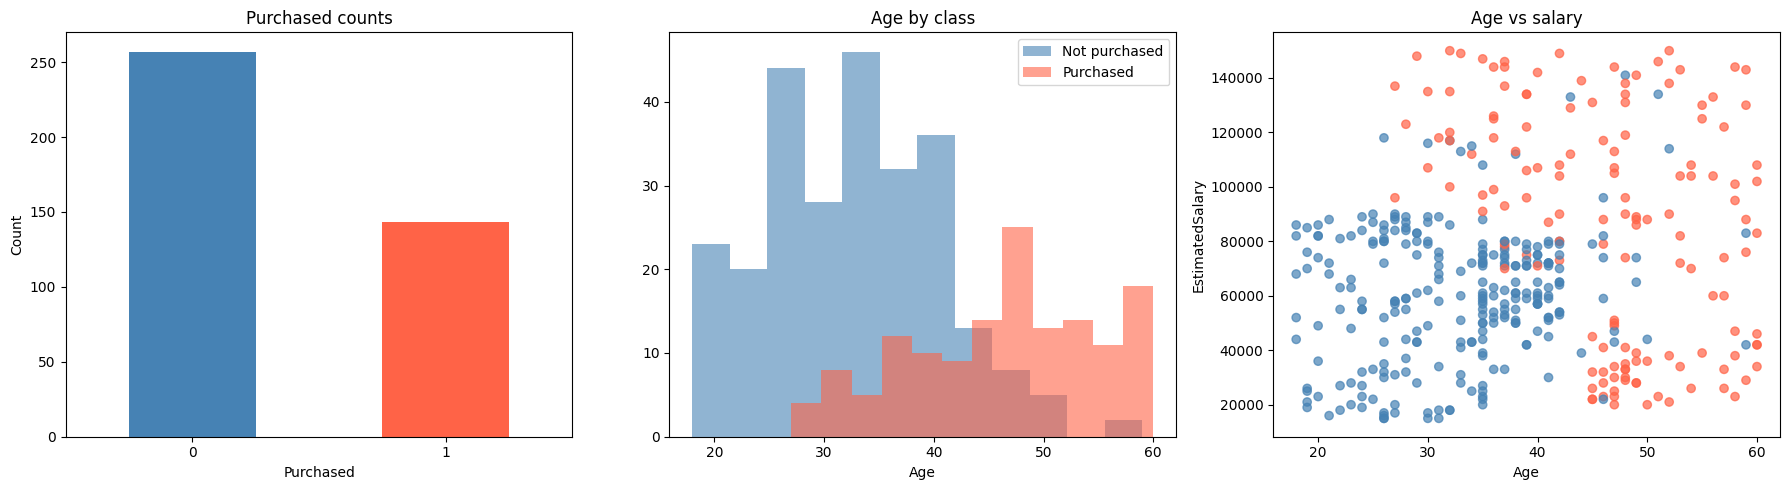

Simple takeaways:
- People who purchased seem older on average.
- Estimated salary also looks higher for the purchased group.
- Gender does not stand out as much as age and salary.


In [5]:
print("Summary of numeric columns:")
display(df[["Age", "EstimatedSalary"]].describe().T)

group_means = df.groupby("Purchased")[["Age", "EstimatedSalary"]].mean()
group_means.index = ["Not Purchased", "Purchased"]
gender_rate = df.groupby("Gender")["Purchased"].mean().rename("purchase_rate")

print("Average values by class:")
display(group_means)

print("Purchase rate by gender:")
display(gender_rate.to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

target_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Purchased counts")
axes[0].set_xlabel("Purchased")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

for value, color, label in [(0, "steelblue", "Not purchased"), (1, "tomato", "Purchased")]:
    axes[1].hist(df[df["Purchased"] == value]["Age"], bins=12, alpha=0.6, color=color, label=label)
axes[1].set_title("Age by class")
axes[1].set_xlabel("Age")
axes[1].legend()

colors = df["Purchased"].map({0: "steelblue", 1: "tomato"})
axes[2].scatter(df["Age"], df["EstimatedSalary"], c=colors, alpha=0.7)
axes[2].set_title("Age vs salary")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("EstimatedSalary")

plt.tight_layout()
plt.show()

print("Simple takeaways:")
print("- People who purchased seem older on average.")
print("- Estimated salary also looks higher for the purchased group.")
print("- Gender does not stand out as much as age and salary.")

## 4. Prepare the data

In [6]:
X = df.drop(columns=["Purchased", "User ID"])
y = df["Purchased"]

categorical_features = ["Gender"]
numeric_features = ["Age", "EstimatedSalary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target share:")
display(y_train.value_counts(normalize=True).sort_index().rename("share").to_frame())
print("Test target share:")
display(y_test.value_counts(normalize=True).sort_index().rename("share").to_frame())

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessing is ready.")

Train shape: (320, 3)
Test shape: (80, 3)

Train target share:


,share
Purchased,
0,0.6438
1,0.3563


Test target share:


,share
Purchased,
0,0.6375
1,0.3625


Preprocessing is ready.


## 5. Train and compare models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

results = []
trained_pipelines = {}
reports = {}
matrices = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    results.append(
        {
            "Model": name,
            "CV Accuracy": cv_scores["test_accuracy"].mean(),
            "CV Precision": cv_scores["test_precision"].mean(),
            "CV Recall": cv_scores["test_recall"].mean(),
            "CV F1": cv_scores["test_f1"].mean(),
            "Test Accuracy": accuracy_score(y_test, preds),
            "Test Precision": precision_score(y_test, preds),
            "Test Recall": recall_score(y_test, preds),
            "Test F1": f1_score(y_test, preds),
        }
    )

    trained_pipelines[name] = pipeline
    reports[name] = pd.DataFrame(classification_report(y_test, preds, output_dict=True)).transpose()
    matrices[name] = confusion_matrix(y_test, preds)

comparison_df = pd.DataFrame(results).sort_values(["CV F1", "Test F1", "Test Accuracy"], ascending=False).reset_index(drop=True)
comparison_df = comparison_df.round(4)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best baseline model:", best_model_name)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Support Vector Machine,0.9094,0.8584,0.8957,0.8748,0.9000,0.8387,0.8966,0.8667
1,K-Nearest Neighbors,0.9062,0.8401,0.9130,0.8739,0.9000,0.8387,0.8966,0.8667
2,Random Forest,0.8938,0.8343,0.8775,0.8538,0.9000,0.8387,0.8966,0.8667
3,Decision Tree,0.8656,0.8075,0.8253,0.8115,0.8625,0.7647,0.8966,0.8254
4,Logistic Regression,0.8438,0.8250,0.7103,0.7606,0.8125,0.8182,0.6207,0.7059


Best baseline model: Support Vector Machine


## 6. Results

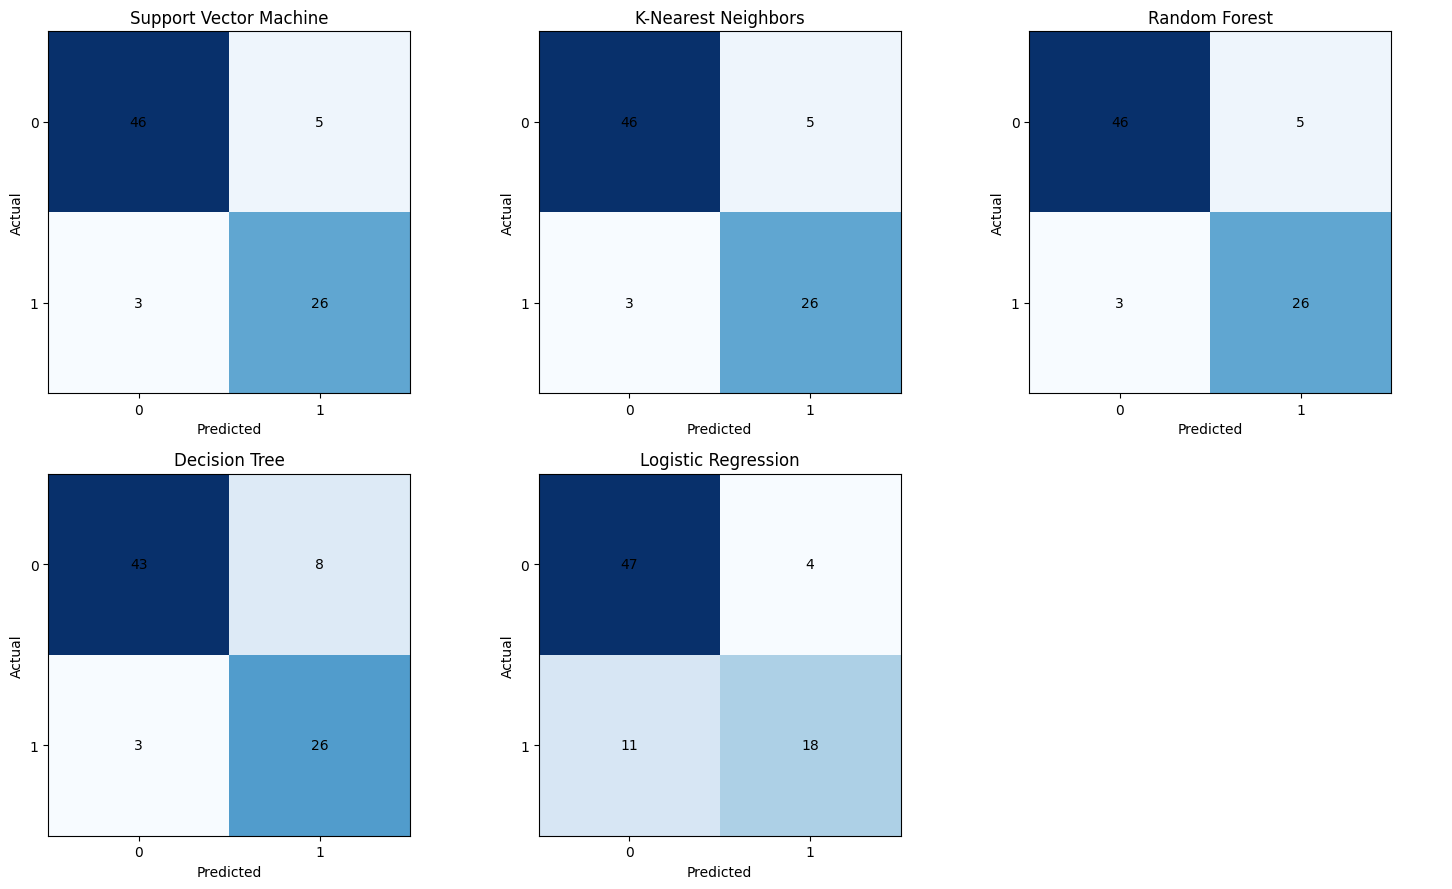

Classification report for the best baseline model:


,precision,recall,f1-score,support
0,0.9388,0.9020,0.9200,51.0000
1,0.8387,0.8966,0.8667,29.0000
accuracy,0.9000,0.9000,0.9000,0.9000
macro avg,0.8887,0.8993,0.8933,80.0000
weighted avg,0.9025,0.9000,0.9007,80.0000


In [8]:
model_names = list(comparison_df["Model"])
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, name in zip(axes, model_names):
    matrix = matrices[name]
    ax.imshow(matrix, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, matrix[i, j], ha="center", va="center", color="black")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Classification report for the best baseline model:")
display(reports[best_model_name].round(4))

## 7. Tune the SVM

Since SVM is the best baseline model, only that model is tuned.

In [9]:
baseline_model_name = "Support Vector Machine"
baseline_pipeline = trained_pipelines[baseline_model_name]
baseline_preds = baseline_pipeline.predict(X_test)
baseline_cv_f1 = comparison_df.loc[comparison_df["Model"] == baseline_model_name, "CV F1"].iloc[0]
baseline_test_f1 = f1_score(y_test, baseline_preds)

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=42)),
])

param_grid = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.1, 0.01, 0.001],
    "model__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    refit=True,
)

grid_search.fit(X_train, y_train)
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

optimization_df = pd.DataFrame(
    [
        {
            "Version": "Baseline SVM",
            "CV F1": baseline_cv_f1,
            "Test Accuracy": accuracy_score(y_test, baseline_preds),
            "Test Precision": precision_score(y_test, baseline_preds),
            "Test Recall": recall_score(y_test, baseline_preds),
            "Test F1": baseline_test_f1,
        },
        {
            "Version": "Tuned SVM",
            "CV F1": grid_search.best_score_,
            "Test Accuracy": accuracy_score(y_test, tuned_preds),
            "Test Precision": precision_score(y_test, tuned_preds),
            "Test Recall": recall_score(y_test, tuned_preds),
            "Test F1": f1_score(y_test, tuned_preds),
        },
    ]
).round(4)

display(optimization_df)
print("Best SVM parameters:")
print(grid_search.best_params_)

if f1_score(y_test, tuned_preds) >= baseline_test_f1:
    selected_final_model_name = "Tuned Support Vector Machine"
    final_model = tuned_model
    final_preds = tuned_preds
    final_cv_f1 = grid_search.best_score_
    final_note = "The tuned SVM was kept because it matched or improved test F1."
else:
    selected_final_model_name = "Support Vector Machine"
    final_model = baseline_pipeline
    final_preds = baseline_preds
    final_cv_f1 = baseline_cv_f1
    final_note = "The original SVM was kept because tuning did not help on the test set."

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_preds),
    "Precision": precision_score(y_test, final_preds),
    "Recall": recall_score(y_test, final_preds),
    "F1": f1_score(y_test, final_preds),
}

print("Final model:", selected_final_model_name)
print(final_note)

,Version,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Baseline SVM,0.8748,0.9000,0.8387,0.8966,0.8667
1,Tuned SVM,0.8748,0.9000,0.8387,0.8966,0.8667


Best SVM parameters:
{'model__C': 1, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Final model: Tuned Support Vector Machine
The tuned SVM was kept because it matched or improved test F1.


## 8. Final result

In [10]:
importance_df = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance": permutation_importance(
            final_model,
            X_test,
            y_test,
            n_repeats=30,
            random_state=42,
            scoring="f1",
        ).importances_mean,
    }
).sort_values("Importance", ascending=False)

importance_df = importance_df.round(4)

print("Final model:", selected_final_model_name)
print(f"CV F1: {final_cv_f1:.4f}")
print(f"Test accuracy: {final_metrics['Accuracy']:.4f}")
print(f"Test precision: {final_metrics['Precision']:.4f}")
print(f"Test recall: {final_metrics['Recall']:.4f}")
print(f"Test F1: {final_metrics['F1']:.4f}")

print("\nFeature importance:")
display(importance_df)

print("Conclusion:")
print(f"- The final model is {selected_final_model_name}.")
print(f"- {final_note}")
print("- Age is the most important feature.")
print("- EstimatedSalary also matters.")
print("- Gender has much less effect in this dataset.")

print("\nLimitations:")
print("- The dataset is small.")
print("- There are only a few useful features.")
print("- The classes are not perfectly balanced.")

print("\nShort summary:")
print("This project predicts whether a customer will purchase based on gender, age, and estimated salary. The SVM gave the best overall results, and age was the strongest feature.")

Final model: Tuned Support Vector Machine
CV F1: 0.8748
Test accuracy: 0.9000
Test precision: 0.8387
Test recall: 0.8966
Test F1: 0.8667

Feature importance:


,Feature,Importance
1,Age,0.3183
2,EstimatedSalary,0.1547
0,Gender,-0.0093


Conclusion:
- The final model is Tuned Support Vector Machine.
- The tuned SVM was kept because it matched or improved test F1.
- Age is the most important feature.
- EstimatedSalary also matters.
- Gender has much less effect in this dataset.

Limitations:
- The dataset is small.
- There are only a few useful features.
- The classes are not perfectly balanced.

Short summary:
This project predicts whether a customer will purchase based on gender, age, and estimated salary. The SVM gave the best overall results, and age was the strongest feature.
